# 🌿 Land Cover Change Analysis (2016–2025)
**City-Wide Barangay-Level Urban Expansion & Vegetation Loss**

Data source: Dynamic World V1 — quarterly land cover proportions per barangay.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')

# ── Palette aligned with land cover semantics ──
CLASS_COLORS = {
    'bare_ground':    '#C2956C',
    'built_area':     '#E05C5C',
    'crops':          '#F0C040',
    'grass':          '#A8D080',
    'shrub_and_scrub':'#6DB38A',
    'trees':          '#2E7D32',
    'water':          '#4A90D9',
}

CLASSES = list(CLASS_COLORS.keys())

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'figure.facecolor': '#F7F7F5',
    'axes.facecolor': '#F7F7F5',
})

print('Libraries loaded ✓')

Libraries loaded ✓


## 1 · Load & Prepare Data

In [ ]:
import time
from IPython.display import display, HTML, clear_output

# ── Loading animation ──────────────────────────────────────────
def loading_screen(message='Loading dataset…', steps=None):
    steps = steps or [
        ('📂', 'Reading CSV file'),
        ('🔍', 'Validating schema'),
        ('🧹', 'Cleaning nulls & types'),
        ('📊', 'Computing annual aggregates'),
        ('✅', 'Ready'),
    ]
    bar_fill = '█'
    bar_empty = '░'
    bar_len = 30
    for i, (icon, label) in enumerate(steps):
        pct = int((i + 1) / len(steps) * 100)
        filled = int(bar_len * (i + 1) / len(steps))
        bar = bar_fill * filled + bar_empty * (bar_len - filled)
        html = f"""
        <div style="font-family:monospace; background:#1e1e2e; color:#cdd6f4;
                    padding:20px 28px; border-radius:10px; width:520px;
                    box-shadow:0 4px 20px rgba(0,0,0,0.4);">
          <div style="font-size:15px; font-weight:bold; margin-bottom:12px;
                      color:#89b4fa;">🌿 Land Cover Analysis</div>
          <div style="font-size:13px; margin-bottom:10px; color:#a6e3a1;">
            {icon} &nbsp; {label}…
          </div>
          <div style="font-size:12px; letter-spacing:1px; color:#89dceb;">
            [{bar}] {pct}%
          </div>
          <div style="font-size:11px; margin-top:8px; color:#6c7086;">
            Step {i+1} / {len(steps)}
          </div>
        </div>
        """
        clear_output(wait=True)
        display(HTML(html))
        time.sleep(0.4)
    clear_output(wait=True)

loading_screen()

# ── Load your file ─────────────────────────────────────────────
FILE_PATH = '/content/time-series-data.csv'   # ← change to your actual path
df = pd.read_csv(FILE_PATH)

# ── Load barangay name mapping ─────────────────────────────────────────────
MAPPING_PATH = '/content/barangay_mapping.csv'   # ← change to your actual mapping path
bgy_map = pd.read_csv(MAPPING_PATH).set_index('baranggay_id')['BRGY_NAME'].to_dict()

def bgy_name(bid):
    """Return barangay name for a given ID, falling back to 'BGY {bid}'."""
    return bgy_map.get(int(bid), f'BGY {bid}')

# ── Basic type enforcement ─────────────────────────────────────
df['year']          = df['year'].astype(int)
df['quarter']       = df['quarter'].astype(int)
df['baranggay_id']  = df['baranggay_id'].astype(int)
for col in CLASSES:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

print(f'✅  Loaded  {len(df):,} rows  |  '
      f'{df.baranggay_id.nunique()} barangays  |  '
      f'Years {df.year.min()}–{df.year.max()}')
df.head()

✅  Loaded  5,160 rows  |  129 barangays  |  Years 2016–2025


,bare_ground,built_area,crops,grass,quarter,shrub_and_scrub,trees,water,year,baranggay_id
0,0.155395,0.746581,0.0,0.0,1,0.055439,0.0,0.00142,2016,1
1,0.070525,0.838666,0.0,0.0,2,0.042585,0.0,0.00142,2016,1
2,0.000000,1.000000,0.0,0.0,3,0.000000,0.0,0.00000,2016,1
3,0.014195,0.936122,0.0,0.0,4,0.001420,0.0,0.00000,2016,1
4,0.092268,0.764361,0.0,0.0,1,0.002839,0.0,0.00000,2017,1


## 2 · Annual Aggregation Helper

In [ ]:
# Annual mean per barangay (average over quarters)
annual = (
    df.groupby(['baranggay_id', 'year'])[CLASSES]
    .mean()
    .reset_index()
)

# City-wide annual mean (average across all barangays, then all quarters)
city_annual = annual.groupby('year')[CLASSES].mean()

# Anchor years
y0, y1 = 2016, 2025
bgy_2016 = annual[annual.year == y0].set_index('baranggay_id')[CLASSES]
bgy_2025 = annual[annual.year == y1].set_index('baranggay_id')[CLASSES]
bgy_delta = bgy_2025 - bgy_2016

print('Aggregations ready ✓')

Aggregations ready ✓


## 3 · Chart 1 — City-Wide Average Land Cover % Change (2016 → 2025)

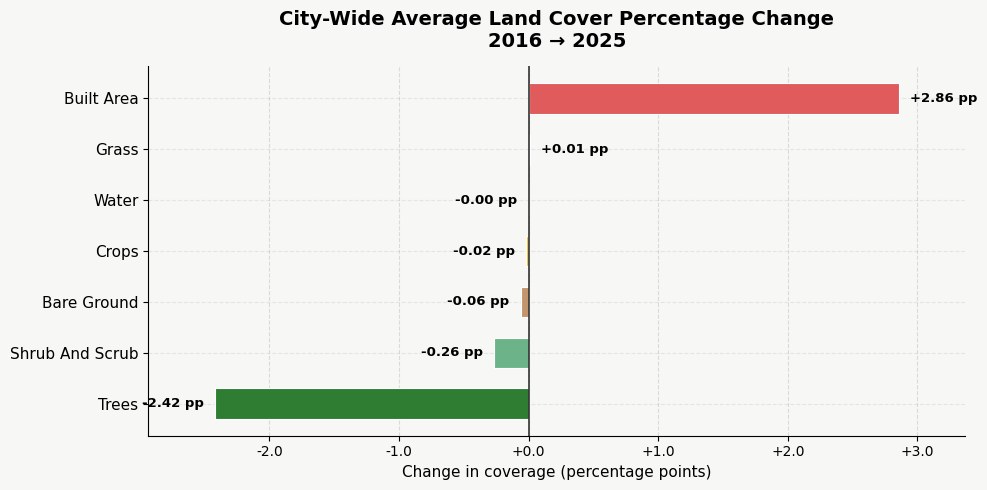

In [ ]:
city_delta = (city_annual.loc[y1] - city_annual.loc[y0]) * 100  # in pp
city_delta_sorted = city_delta.sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#F7F7F5')

colors = [CLASS_COLORS[c] for c in city_delta_sorted.index]
bars = ax.barh(
    city_delta_sorted.index, city_delta_sorted.values,
    color=colors, edgecolor='white', linewidth=0.8, height=0.6
)

ax.axvline(0, color='#333', linewidth=1.2, linestyle='-')

# Compute padding based on data range so labels sit cleanly outside bars
vmax = city_delta_sorted.abs().max()
pad = vmax * 0.03

for bar, val in zip(bars, city_delta_sorted.values):
    # Always place the label OUTSIDE the bar end, away from zero
    if val >= 0:
        x_text = val + pad
        ha = 'left'
    else:
        x_text = val - pad
        ha = 'right'
    ax.text(x_text, bar.get_y() + bar.get_height()/2,
            f'{val:+.2f} pp', va='center', ha=ha,
            fontsize=9.5, fontweight='bold')

# Expand x-limits so labels don't get clipped
ax.set_xlim(city_delta_sorted.min() - vmax * 0.18,
            city_delta_sorted.max() + vmax * 0.18)

ax.set_xlabel('Change in coverage (percentage points)', fontsize=11)
ax.set_title('City-Wide Average Land Cover Percentage Change\n2016 → 2025',
             fontsize=14, fontweight='bold', pad=14)
ax.set_yticklabels([c.replace('_', ' ').title() for c in city_delta_sorted.index], fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:+.1f}'))
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart1_citywide_change.png', dpi=150, bbox_inches='tight')
plt.show()

## 4 · Chart 2 — Top Barangays with Highest Built-Up Area Expansion (2016 → 2025)

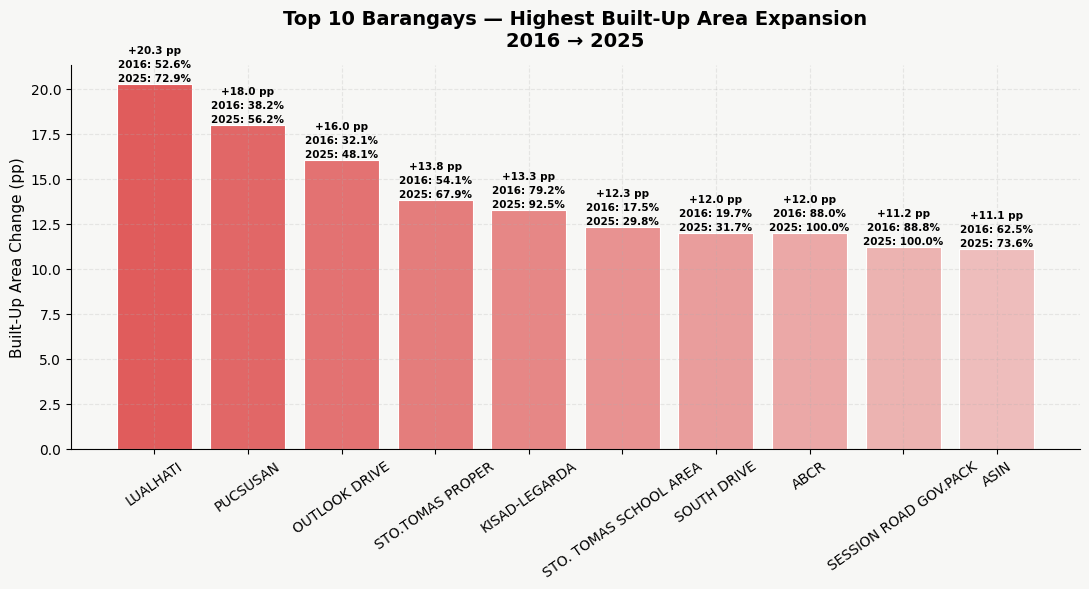

In [ ]:
TOP_N = 10
built_delta = (bgy_delta['built_area'] * 100).sort_values(ascending=False).head(TOP_N)

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#F7F7F5')

gradient_colors = [
    mcolors.to_rgba(CLASS_COLORS['built_area'], alpha=1 - i * 0.07)
    for i in range(TOP_N)
]

bgy_names_chart2 = [bgy_name(i) for i in built_delta.index]

bars = ax.bar(
    bgy_names_chart2,
    built_delta.values,
    color=gradient_colors, edgecolor='white', linewidth=0.8
)

for bar, bid, val in zip(bars, built_delta.index, built_delta.values):
    v2016 = bgy_2016.loc[bid, 'built_area'] * 100 if bid in bgy_2016.index else float('nan')
    v2025 = bgy_2025.loc[bid, 'built_area'] * 100 if bid in bgy_2025.index else float('nan')
    label = f'+{val:.1f} pp\n2016: {v2016:.1f}%\n2025: {v2025:.1f}%'
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            label, ha='center', va='bottom', fontsize=7.5, fontweight='bold', linespacing=1.5)

ax.set_ylabel('Built-Up Area Change (pp)', fontsize=11)
ax.set_title(f'Top {TOP_N} Barangays — Highest Built-Up Area Expansion\n2016 → 2025',
             fontsize=14, fontweight='bold', pad=14)
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.savefig('chart2_builtup_expansion.png', dpi=150, bbox_inches='tight')
plt.show()


## 5 · Chart 3 — Built-Up Area Trends for Top 5 Expanding Barangays (2016–2025)

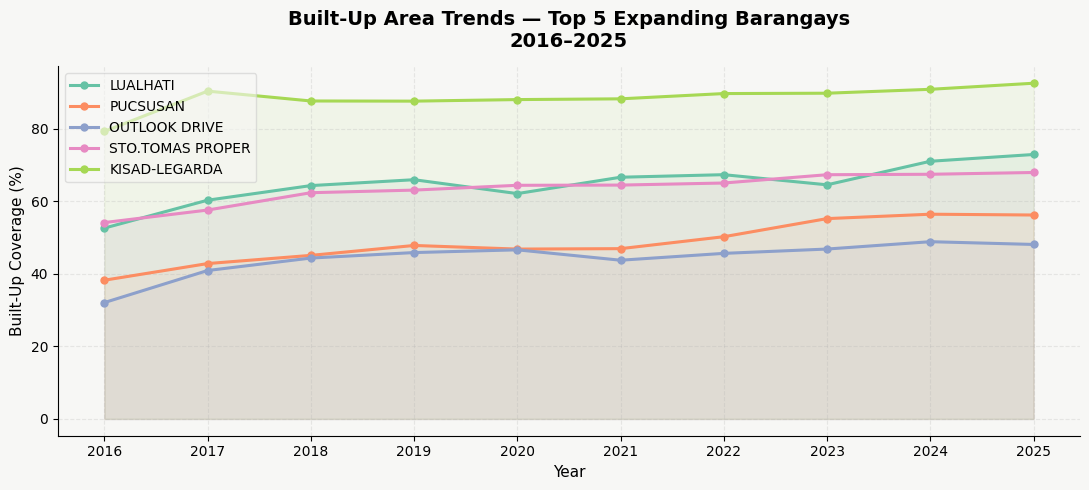

In [ ]:
top5_ids = built_delta.head(5).index.tolist()
top5_data = annual[annual.baranggay_id.isin(top5_ids)]

palette = sns.color_palette('Set2', 5)

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('#F7F7F5')

for color, bid in zip(palette, top5_ids):
    sub = top5_data[top5_data.baranggay_id == bid].groupby('year')['built_area'].mean() * 100
    ax.plot(sub.index, sub.values, marker='o', markersize=5,
            linewidth=2.2, color=color, label=bgy_name(bid))
    ax.fill_between(sub.index, sub.values, alpha=0.08, color=color)

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Built-Up Coverage (%)', fontsize=11)
ax.set_title('Built-Up Area Trends — Top 5 Expanding Barangays\n2016–2025',
             fontsize=14, fontweight='bold', pad=14)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.legend(framealpha=0.6, fontsize=10)
plt.tight_layout()
plt.savefig('chart3_builtup_trends.png', dpi=150, bbox_inches='tight')
plt.show()


## 6 · Chart 4 — Top Barangays with Highest Tree Cover Loss (2016 → 2025)

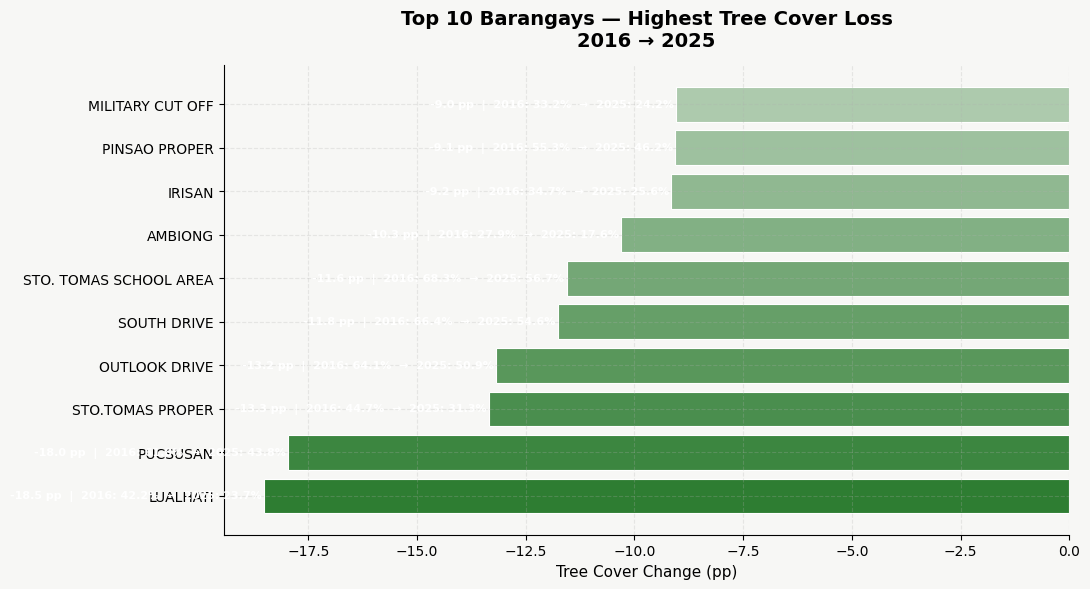

In [ ]:
tree_loss = (bgy_delta['trees'] * 100).sort_values().head(TOP_N)  # most negative first

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#F7F7F5')

loss_colors = [
    mcolors.to_rgba(CLASS_COLORS['trees'], alpha=1 - i * 0.07)
    for i in range(TOP_N)
]

bgy_names_chart4 = [bgy_name(i) for i in tree_loss.index]

bars = ax.barh(
    bgy_names_chart4,
    tree_loss.values,
    color=loss_colors, edgecolor='white', linewidth=0.8
)

for bar, bid, val in zip(bars, tree_loss.index, tree_loss.values):
    v2016 = bgy_2016.loc[bid, 'trees'] * 100 if bid in bgy_2016.index else float('nan')
    v2025 = bgy_2025.loc[bid, 'trees'] * 100 if bid in bgy_2025.index else float('nan')
    label = f'{val:.1f} pp  |  2016: {v2016:.1f}%  →  2025: {v2025:.1f}%'
    ax.text(val - 0.05, bar.get_y() + bar.get_height()/2,
            label, va='center', ha='right', fontsize=8, fontweight='bold', color='white')

ax.set_xlabel('Tree Cover Change (pp)', fontsize=11)
ax.set_title(f'Top {TOP_N} Barangays — Highest Tree Cover Loss\n2016 → 2025',
             fontsize=14, fontweight='bold', pad=14)
plt.tight_layout()
plt.savefig('chart4_tree_loss.png', dpi=150, bbox_inches='tight')
plt.show()


## 7 · Chart 5 — Barangays with Notable Land Cover Class Transitions (2016 → 2025)
"Notable" = absolute sum of per-class changes across all classes is largest (most dynamic barangays).

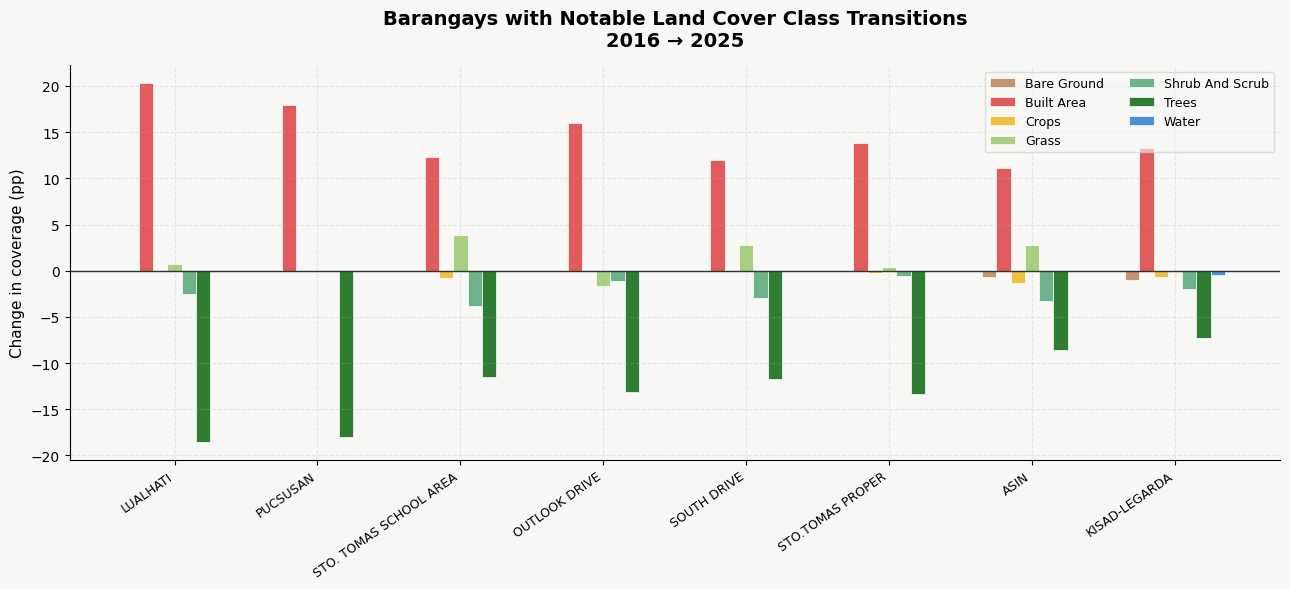

In [ ]:
dynamism = (bgy_delta.abs().sum(axis=1)).sort_values(ascending=False).head(8)
top_dynamic = bgy_delta.loc[dynamism.index] * 100

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#F7F7F5')

bgy_names_chart5 = [bgy_name(i) for i in top_dynamic.index]
x = np.arange(len(top_dynamic))
n_classes = len(CLASSES)
width = 0.10
offsets = np.linspace(-(n_classes-1)/2, (n_classes-1)/2, n_classes) * width

for offset, cls in zip(offsets, CLASSES):
    ax.bar(x + offset, top_dynamic[cls], width=width,
           color=CLASS_COLORS[cls], edgecolor='white', linewidth=0.5,
           label=cls.replace('_', ' ').title())

ax.axhline(0, color='#333', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(bgy_names_chart5, rotation=35, fontsize=9, ha='right')
ax.set_ylabel('Change in coverage (pp)', fontsize=11)
ax.set_title('Barangays with Notable Land Cover Class Transitions\n2016 → 2025',
             fontsize=14, fontweight='bold', pad=14)
ax.legend(loc='upper right', ncol=2, fontsize=9, framealpha=0.6)
plt.tight_layout()
plt.savefig('chart5_class_transitions.png', dpi=150, bbox_inches='tight')
plt.show()


## 8 · Chart 6 — Correlation Matrix of Land Cover Classes Across All Barangays (2016–2025)

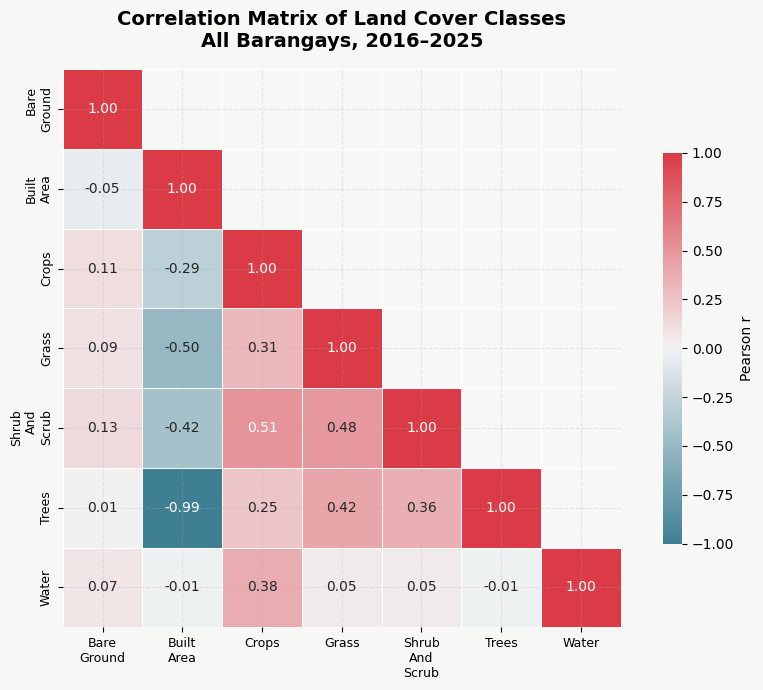

In [ ]:
# Use annual barangay-level means — one row per (barangay, year)
corr = annual[CLASSES].corr()

pretty_labels = [c.replace('_', '\n').title() for c in CLASSES]

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor('#F7F7F5')

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # show lower triangle + diag
cmap = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap=cmap,
    vmin=-1, vmax=1, center=0,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 10},
    xticklabels=pretty_labels, yticklabels=pretty_labels,
    ax=ax, square=True,
    cbar_kws={'shrink': 0.7, 'label': 'Pearson r'}
)

ax.set_title('Correlation Matrix of Land Cover Classes\nAll Barangays, 2016–2025',
             fontsize=14, fontweight='bold', pad=16)
ax.tick_params(axis='both', labelsize=9)
plt.tight_layout()
plt.savefig('chart6_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 9 · Chart 7 — Tree Cover Trends for Top 5 Barangays with Highest Vegetation Loss (2016–2025)
Track how tree cover evolved year-by-year for the barangays that lost the most vegetation.

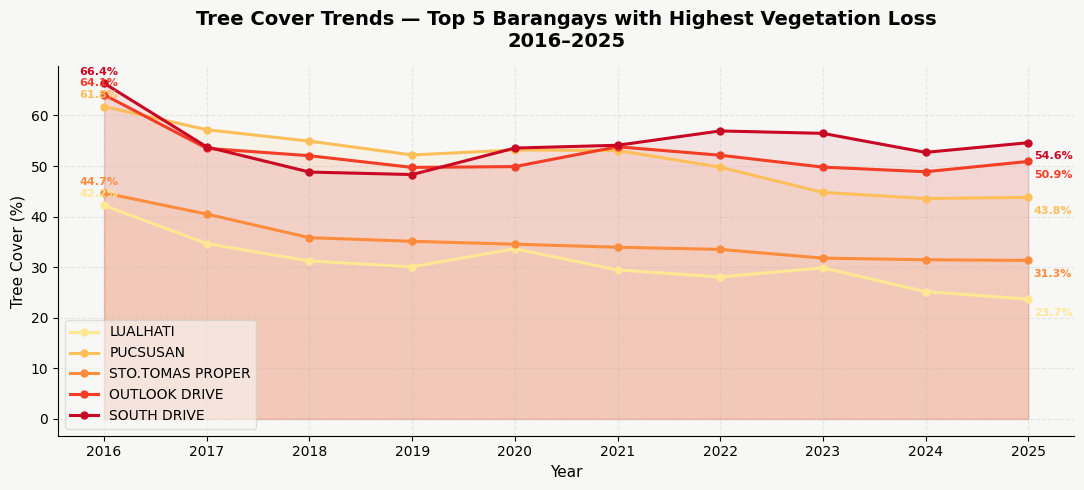

In [ ]:
# ── Top 5 barangays with highest TREE cover loss (most negative delta) ──
top5_veg_loss_ids = (bgy_delta['trees'] * 100).sort_values().head(5).index.tolist()
top5_veg_data = annual[annual.baranggay_id.isin(top5_veg_loss_ids)]

palette_veg = sns.color_palette('YlOrRd', 5)

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('#F7F7F5')

for color, bid in zip(palette_veg, top5_veg_loss_ids):
    sub = top5_veg_data[top5_veg_data.baranggay_id == bid] \
        .groupby('year')['trees'].mean() * 100

    ax.plot(
        sub.index,
        sub.values,
        marker='o',
        markersize=5,
        linewidth=2.2,
        color=color,
        label=bgy_name(bid)
    )
    ax.fill_between(sub.index, sub.values, alpha=0.08, color=color)

# ── Annotate start and end values ──
for color, bid in zip(palette_veg, top5_veg_loss_ids):
    sub = top5_veg_data[top5_veg_data.baranggay_id == bid] \
        .groupby('year')['trees'].mean() * 100

    if not sub.empty:
        ax.annotate(
            f'{sub.iloc[0]:.1f}%',
            xy=(sub.index[0], sub.iloc[0]),
            xytext=(-18, 6),
            textcoords='offset points',
            fontsize=8,
            color=color,
            fontweight='bold'
        )
        ax.annotate(
            f'{sub.iloc[-1]:.1f}%',
            xy=(sub.index[-1], sub.iloc[-1]),
            xytext=(4, -12),
            textcoords='offset points',
            fontsize=8,
            color=color,
            fontweight='bold'
        )

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Tree Cover (%)', fontsize=11)
ax.set_title(
    'Tree Cover Trends — Top 5 Barangays with Highest Vegetation Loss\n2016–2025',
    fontsize=14,
    fontweight='bold',
    pad=14
)

ax.xaxis.set_major_locator(mticker.MultipleLocator(1))

# ✅ Legend moved to bottom-left
ax.legend(
    framealpha=0.6,
    fontsize=10,
    loc='lower left'
)

plt.tight_layout()
plt.savefig('chart7_tree_cover_trends_top5_veg_loss.png', dpi=150, bbox_inches='tight')
plt.show()

## 10 · Chart 8 — Land Cover Class Transition Trends for Selected Barangays (2016–2025)
Multi-panel time-series showing how each land cover class evolved across the top 5 most-dynamic barangays.
"Selected" = top 5 barangays by overall dynamism (largest absolute sum of changes).

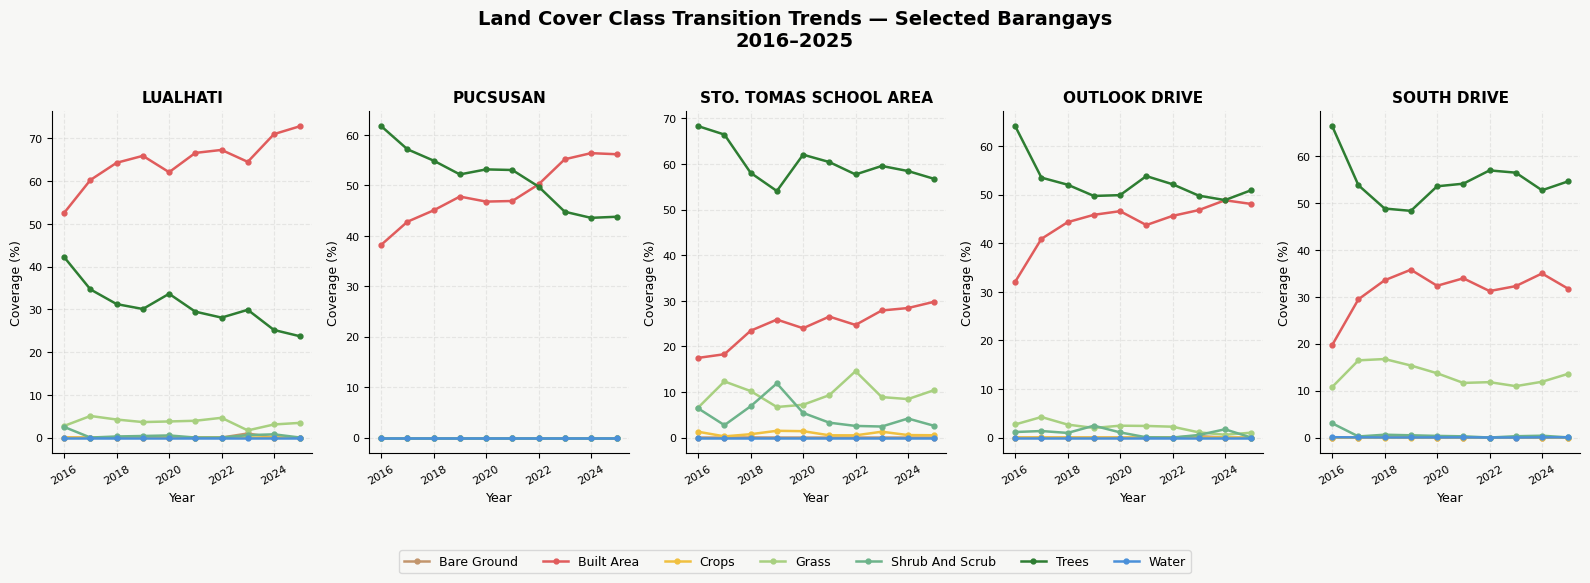

In [ ]:
# ── Selected barangays: top 5 most dynamic (highest total abs class change) ──
selected_ids = (bgy_delta.abs().sum(axis=1)).sort_values(ascending=False).head(5).index.tolist()
selected_data = annual[annual.baranggay_id.isin(selected_ids)]

fig, axes = plt.subplots(1, len(selected_ids), figsize=(16, 5), sharey=False)
fig.patch.set_facecolor('#F7F7F5')
fig.suptitle('Land Cover Class Transition Trends — Selected Barangays\n2016–2025',
             fontsize=14, fontweight='bold', y=1.02)

for ax, bid in zip(axes, selected_ids):
    sub = selected_data[selected_data.baranggay_id == bid].groupby('year')[CLASSES].mean() * 100
    for cls in CLASSES:
        ax.plot(sub.index, sub[cls], marker='o', markersize=3.5,
                linewidth=1.8, color=CLASS_COLORS[cls],
                label=cls.replace('_', ' ').title())
    ax.set_title(bgy_name(bid), fontsize=11, fontweight='bold')
    ax.set_xlabel('Year', fontsize=9)
    ax.set_ylabel('Coverage (%)', fontsize=9)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=7, fontsize=9,
           framealpha=0.7, bbox_to_anchor=(0.5, -0.12))

plt.tight_layout()
plt.savefig('chart8_class_transition_trends.png', dpi=150, bbox_inches='tight')
plt.show()


## 11 · Chart 9 — Comparative Land Cover Trends Across Selected Barangays (2016–2025)
Faceted stacked-area chart: one panel per land cover class, comparing the same set of selected barangays side-by-side to highlight divergent trajectories.

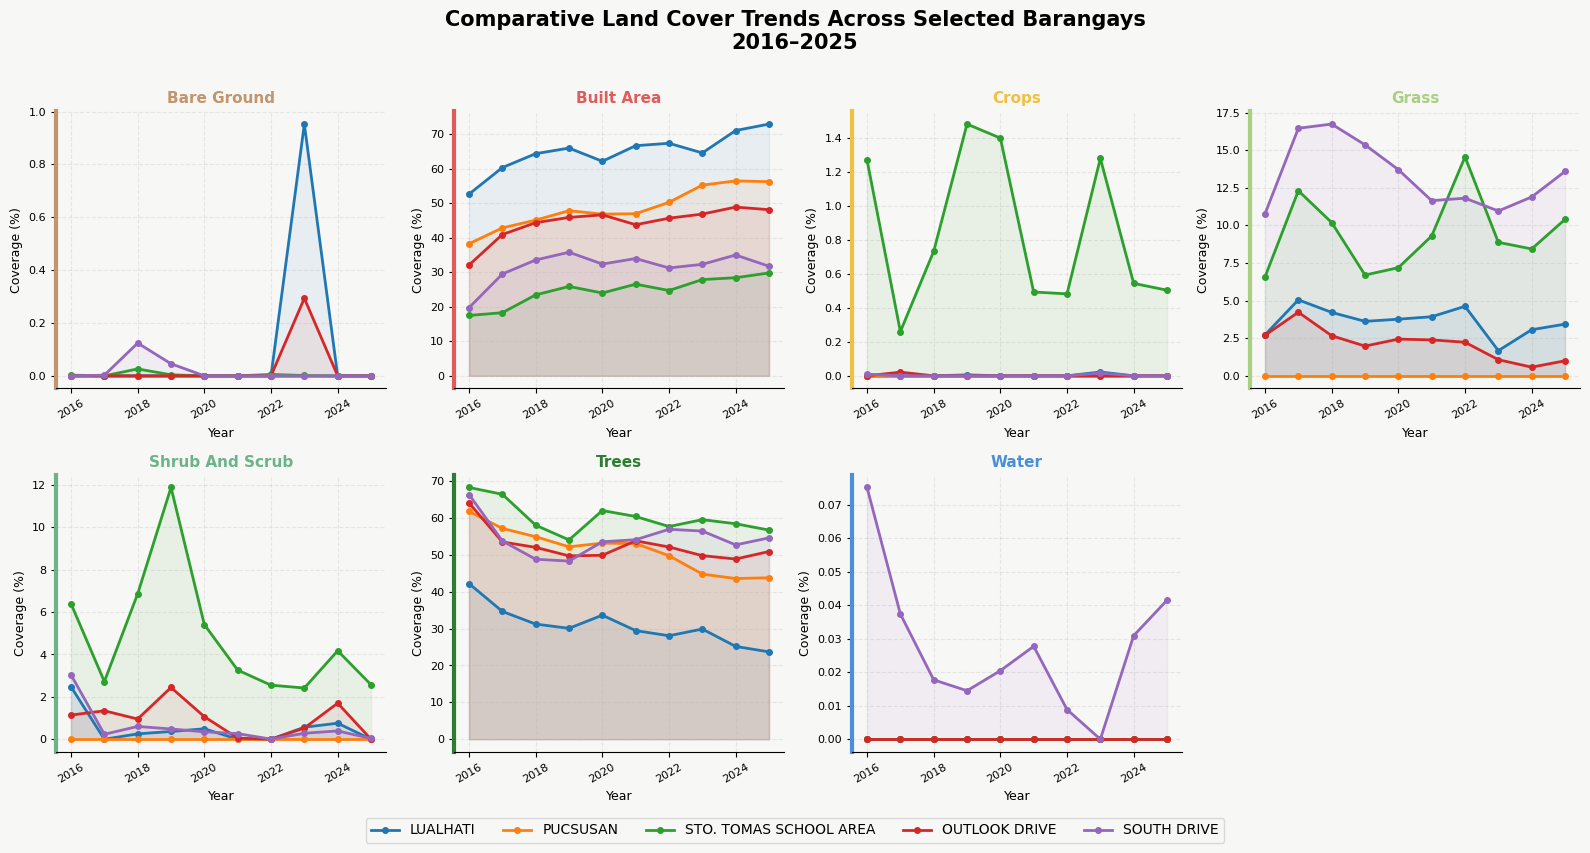

In [ ]:
# ── Reuse the same selected_ids from Chart 8 ──
n_classes = len(CLASSES)
n_cols = 4
n_rows = (n_classes + n_cols - 1) // n_cols

bgy_palette = sns.color_palette('tab10', len(selected_ids))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4), sharey=False)
fig.patch.set_facecolor('#F7F7F5')
fig.suptitle('Comparative Land Cover Trends Across Selected Barangays\n2016–2025',
             fontsize=15, fontweight='bold', y=1.01)

axes_flat = axes.flatten()

for idx, cls in enumerate(CLASSES):
    ax = axes_flat[idx]
    ax.set_facecolor('#F7F7F5')
    cls_color = CLASS_COLORS[cls]

    for bgy_color, bid in zip(bgy_palette, selected_ids):
        sub = (selected_data[selected_data.baranggay_id == bid]
               .groupby('year')[cls].mean() * 100)
        ax.plot(sub.index, sub.values, marker='o', markersize=4,
                linewidth=2, color=bgy_color, label=bgy_name(bid))
        ax.fill_between(sub.index, sub.values, alpha=0.07, color=bgy_color)

    # Class colour band as left spine accent
    ax.spines['left'].set_color(cls_color)
    ax.spines['left'].set_linewidth(3)

    ax.set_title(cls.replace('_', ' ').title(), fontsize=11, fontweight='bold',
                 color=cls_color)
    ax.set_xlabel('Year', fontsize=9)
    ax.set_ylabel('Coverage (%)', fontsize=9)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

# Hide any unused subplots
for ax in axes_flat[n_classes:]:
    ax.set_visible(False)

# Shared legend
handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(selected_ids),
           fontsize=10, framealpha=0.7, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.savefig('chart9_comparative_land_cover_trends.png', dpi=150, bbox_inches='tight')
plt.show()


---
### Summary Statistics

In [ ]:
summary = pd.DataFrame({
    'Mean 2016 (%)': bgy_2016.mean() * 100,
    'Mean 2025 (%)': bgy_2025.mean() * 100,
    'Δ (pp)': bgy_delta.mean() * 100,
    'Max Gain (pp)': bgy_delta.max() * 100,
    'Max Loss (pp)': bgy_delta.min() * 100,
}).round(3)

summary.index = [c.replace('_', ' ').title() for c in summary.index]
summary.style.background_gradient(subset=['Δ (pp)'], cmap='RdYlGn').format('{:.2f}')

,Mean 2016 (%),Mean 2025 (%),Δ (pp),Max Gain (pp),Max Loss (pp)
Bare Ground,0.06,0.00,-0.06,0.08,-6.00
Built Area,84.88,87.74,2.85,20.28,-4.13
Crops,0.05,0.03,-0.02,0.45,-1.29
Grass,0.41,0.41,0.01,3.82,-2.07
Shrub And Scrub,0.32,0.05,-0.26,0.16,-3.82
Trees,14.16,11.74,-2.42,5.05,-18.52
Water,0.03,0.03,-0.00,0.14,-0.44
